In [ ]:
# CARREGANDO E PREPARANDO O DATASET

from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import numpy as np

# Carregando os dados
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# Normalizando (pixels de 0-255 para 0-1) e transformando imagens 28x28 em vetores de 784 valores (para MLP)
X = X / 255.0
X  = X.reshape(-1, 784)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Total de imagens:  {X_train.shape[0] + X_test.shape[0]}")
print(f"Imagens de treino: {X_train.shape[0]} imagens de {X_train.shape[1]} pixels cada")
print(f"Imagens de teste:  {X_test.shape[0]} imagens de {X_test.shape[1]} pixels cada")

Total de imagens:  70000
Imagens de treino: 60000 imagens de 784 pixels cada
Imagens de teste:  10000 imagens de 784 pixels cada


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64,  activation='relu'),
    Dense(10,  activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,   # 10% do treino vira validação
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9904 - loss: 0.0322 - val_accuracy: 0.9760 - val_loss: 0.1150
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9802 - val_loss: 0.0892
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9937 - loss: 0.0189 - val_accuracy: 0.9795 - val_loss: 0.0950
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9953 - loss: 0.0136 - val_accuracy: 0.9777 - val_loss: 0.1083
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9950 - loss: 0.0148 - val_accuracy: 0.9783 - val_loss: 0.1177
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9956 - loss: 0.0127 - val_accuracy: 0.9805 - val_loss: 0.1090
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9961 - loss: 0.0127 - val_accuracy: 0.9778 - val_loss: 0.1162
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9963 - loss: 0.0113 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


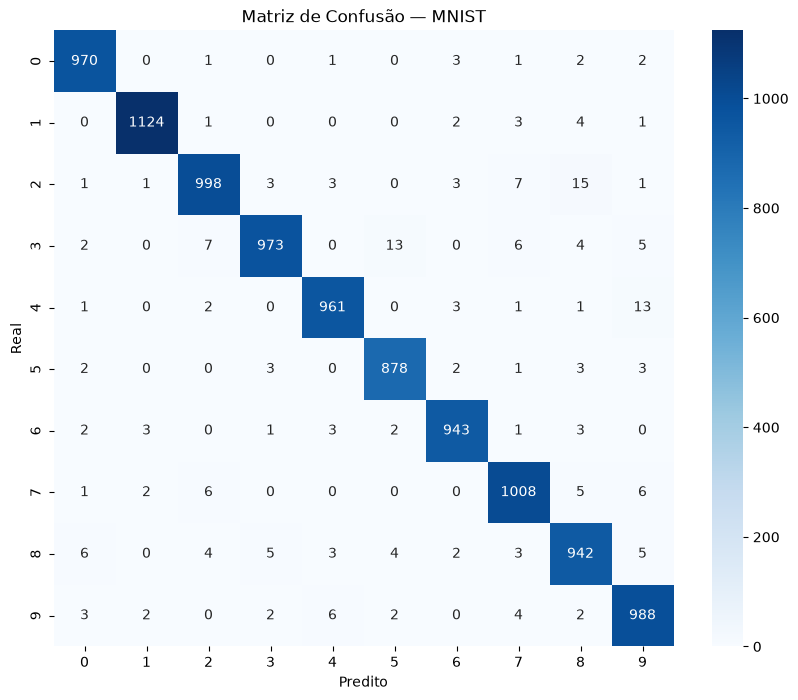

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.99      0.96      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.96      0.97      0.96       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão — MNIST')
plt.savefig('matriz_confusao.png')
plt.show()

print(classification_report(y_test, y_pred))

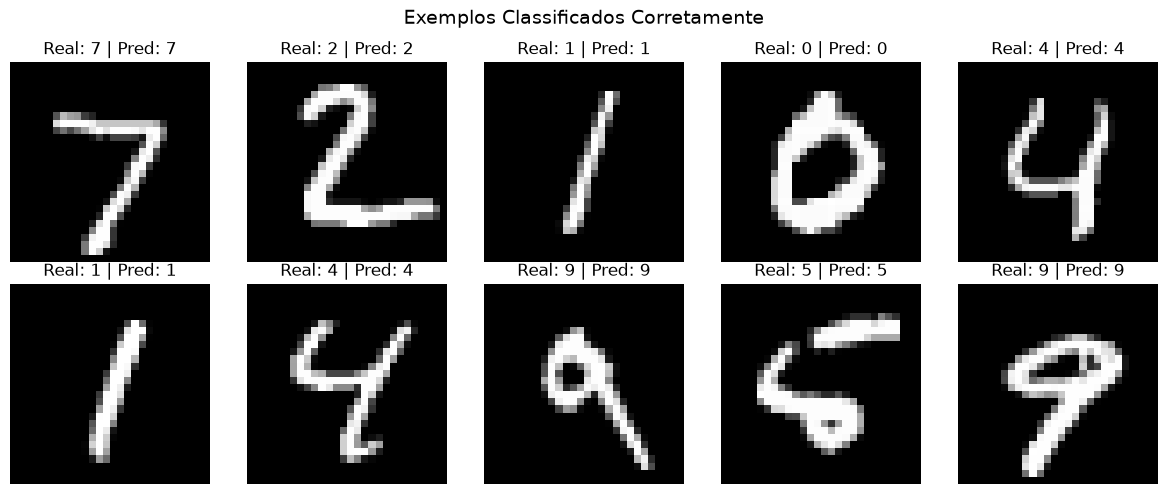

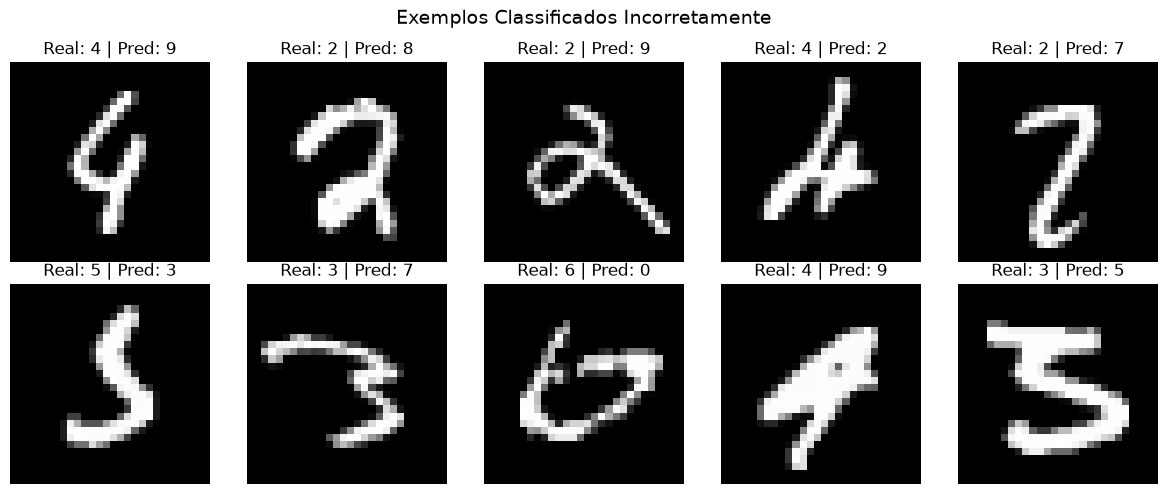

In [8]:
# Separar índices de acertos e erros
acertos = np.where(y_pred == y_test)[0]
erros   = np.where(y_pred != y_test)[0]

def plotar_exemplos(indices, titulo, X, y_real, y_pred, n=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(titulo, fontsize=14)
    for i, ax in enumerate(axes.flat):
        idx = indices[i]
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Real: {y_real[idx]} | Pred: {y_pred[idx]}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{titulo.lower().replace(" ","_")}.png')
    plt.show()

plotar_exemplos(acertos, 'Exemplos Classificados Corretamente',
                X_test, y_test, y_pred)
plotar_exemplos(erros,   'Exemplos Classificados Incorretamente',
                X_test, y_test, y_pred)

In [9]:
import pandas as pd

# Quais pares (real → predito) aparecem mais nos erros
erros_df = pd.DataFrame({
    'real': y_test[erros],
    'predito': y_pred[erros]
})

print(erros_df.groupby(['real','predito']).size()
              .sort_values(ascending=False)
              .head(10))

real  predito
2     8          15
3     5          13
4     9          13
3     2           7
2     7           7
3     7           6
9     4           6
7     2           6
      9           6
8     0           6
dtype: int64
